# Pipeline walkthrough — every transformation, step by step

This notebook runs the **actual** functions in `core/` and narrates what each does and *why*. Order of operations:

1. **Normalizers** — field-level cleaning (5 rules).
2. **`preprocess_tic`** — normalize + collapse the payer side to the match grain.
3. **`preprocess_hpt`** — filter + normalize + collapse the hospital side.
4. **`match_rates`** — Pass 1 (strict) → Pass 2 (billing-relaxed) → Pass 3 (rate-value corroboration) → assembly.
5. **Output + stats** — the 41-row unified table and what to look at.

Run top to bottom. Needs `pandas` (+ `matplotlib` for the final chart).

In [1]:
# --- setup: find repo root, import the real pipeline code ---
import sys
from pathlib import Path
import pandas as pd
ROOT = Path.cwd()
while not (ROOT / "core").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 170)

from core import normalizers as N
from core.match import (PipelineStats, preprocess_tic, preprocess_hpt, match_rates, run,
                        OUTPUT_COLUMNS, KEY_COLS)
aliases = N.load_payer_aliases(ROOT / "core" / "payer_aliases.json")
TIC_PATH = ROOT / "data" / "tic_extract_20250213.csv"
HPT_PATH = ROOT / "data" / "hpt_extract_20250213.csv"
print("imported core.match + core.normalizers; KEY_COLS =", KEY_COLS)

imported core.match + core.normalizers; KEY_COLS = ['_ein', '_code', '_code_type', '_payer', '_billing']


## 0. The shape of the pipeline

```
TiC raw (222) ─ normalize ─ collapse ─▶ 34 match groups ┐
                                                         ├─ Pass1 strict ─ Pass2 relaxed ─ Pass3 corroborate ─▶ 41 unified rows
HPT raw (2,950) ─ filter ─ normalize ─ collapse ─▶ 37 ──┘
```
Both sides are collapsed to the **same grain** — `(ein, code, code_type, payer, billing_class)` — *before* matching, so the join is symmetric and the output is one row per key.

## 1. Normalizers (`core/normalizers.py`)

Five field-level rules. Each is small, pure, and unit-tested. Live demos:

In [2]:
# (a) EIN: strip to 9 digits, zero-pad
print("normalize_ein('13-1740114') =", N.normalize_ein("13-1740114"))
# (b) EIN from the HPT filename prefix (the reliable cross-file key)
print("ein_from_hpt_source_file('131624096_MountSinai_standardcharges.csv') =",
      N.ein_from_hpt_source_file("131624096_MountSinai_standardcharges.csv"))
print("normalize_ein(state cert '330024') =", N.normalize_ein("330024"), " <- NOT a federal EIN")

normalize_ein('13-1740114') = 131740114
ein_from_hpt_source_file('131624096_MountSinai_standardcharges.csv') = 131624096
normalize_ein(state cert '330024') = 000330024  <- NOT a federal EIN


In [3]:
# (c) DRG code shape: strip prefixes and leading zeros
for raw in ["MS-DRG 872", "872", "0872"]:
    print(f"normalize_code({raw!r:12}, 'MS-DRG') = {N.normalize_code(raw, 'MS-DRG')!r}")

normalize_code('MS-DRG 872', 'MS-DRG') = '872'
normalize_code('872'       , 'MS-DRG') = '872'
normalize_code('0872'      , 'MS-DRG') = '872'


In [4]:
# (d) Payer canonicalization with a guard against silent over-match
for s in ["Aetna", "UHC", "Cigna PPO", "United Mine Workers", "ci"]:
    print(f"normalize_payer({s!r:20}) = {N.normalize_payer(s, aliases)!r}")
print("\n('United Mine Workers' and 'ci' must be None -- not UnitedHealthcare/Cigna)")

normalize_payer('Aetna'             ) = 'aetna'
normalize_payer('UHC'               ) = 'unitedhealthcare'
normalize_payer('Cigna PPO'         ) = 'cigna'
normalize_payer('United Mine Workers') = None
normalize_payer('ci'                ) = None

('United Mine Workers' and 'ci' must be None -- not UnitedHealthcare/Cigna)


In [5]:
# (e) Billing-class inference for HPT (which has no billing_class field)
cases = [("MS-DRG","Septicemia","inpatient"),
         ("CPT","HC Egd Transoral Biopsy","outpatient"),
         ("CPT","PR Edg biopsy","outpatient"),
         ("CPT","Egd biopsy single/multiple","outpatient")]  # <- the $6,438 row: no HC -> unknown
for ct,desc,setting in cases:
    print(f"{N.infer_hpt_billing_class(ct,desc,setting):13} <- ({ct}, {desc!r}, {setting})")

institutional <- (MS-DRG, 'Septicemia', inpatient)
institutional <- (CPT, 'HC Egd Transoral Biopsy', outpatient)
professional  <- (CPT, 'PR Edg biopsy', outpatient)
unknown       <- (CPT, 'Egd biopsy single/multiple', outpatient)


**Note the last line:** the genuinely-institutional `$6,438` HPT row has no `HC ` prefix, so it infers `unknown`. That single weakness is why Pass 3 exists.

## 2. `preprocess_tic` — normalize + collapse the payer side

Steps inside the function: drop `percentage` rows → normalize key fields → group to one row per key, aggregating rate to median/min/max + a count, taking the **median** CMS baseline, and joining distinct schedules / negotiation types.

In [6]:
tic_raw = pd.read_csv(TIC_PATH, dtype=str)
print("TiC raw rows:", len(tic_raw))
# Step 2a - the 3 percentage rows are dropped (rate=70 means "70% of baseline", not $70)
pct = tic_raw.negotiation_type.str.lower() == "percentage"
print("dropping percentage rows:", int(pct.sum()))
tic_raw.loc[pct, ["payer","code","negotiation_type","rate","cms_baseline_rate"]]

TiC raw rows: 222
dropping percentage rows: 3


,payer,code,negotiation_type,rate,cms_baseline_rate
40,aetna,99283,percentage,70,276.89
146,aetna,43239,percentage,70,424.76
160,aetna,99283,percentage,70,78.59


In [7]:
# Step 2b - what the normalized key columns look like (shown on a sample)
demo = tic_raw[~pct].copy()
demo["_ein"]     = demo.ein.apply(N.normalize_ein)
demo["_code"]    = demo.apply(lambda r: N.normalize_code(r.code, r.code_type), axis=1)
demo["_payer"]   = demo.payer.apply(lambda x: N.normalize_payer(x, aliases))
demo["_billing"] = demo.billing_class.str.lower().str.strip()
demo[["payer","_payer","code","_code","billing_class","_billing","rate"]].head(6)

,payer,_payer,code,_code,billing_class,_billing,rate
0,unitedhealthcare,unitedhealthcare,872,872,institutional,institutional,15902
1,unitedhealthcare,unitedhealthcare,99283,99283,professional,professional,123.86
2,unitedhealthcare,unitedhealthcare,43239,43239,professional,professional,993.92
3,unitedhealthcare,unitedhealthcare,872,872,institutional,institutional,27924.63
4,unitedhealthcare,unitedhealthcare,43239,43239,professional,professional,849.63
5,unitedhealthcare,unitedhealthcare,99283,99283,professional,professional,55.04


In [8]:
# Step 2c - run the real function and inspect the collapsed result
stats = PipelineStats()
tic = preprocess_tic(tic_raw, aliases, stats)
print(f"{len(tic_raw)} raw -> {stats.tic_rows_after_filter} after filter -> {stats.tic_match_groups} match groups")
tic.head(6)

222 raw -> 219 after filter -> 34 match groups


,_ein,_code,_code_type,_payer,_billing,tic_rate_median,tic_rate_min,tic_rate_max,tic_npi_group_count,cms_baseline_rate,cms_baseline_schedule,network_name_tic,tic_negotiation_types,_rate_values,cms_baseline_mixed
0,131624096,43239,CPT,aetna,institutional,4465.500,1766.00,5845.00,4,937.560,OPPS,open-access-managed-choice,negotiated,"(5228.0, 5845.0, 1766.0, 3703.0)",False
1,131624096,43239,CPT,aetna,professional,2078.320,168.25,5228.00,4,151.420,PFS_FACILITY_1320201; PFS_FACILITY_1329204; PF...,open-access-managed-choice,fee schedule; negotiated,"(168.25, 5228.0, 453.64, 3703.0)",True
2,131624096,43239,CPT,cigna,professional,514.575,164.00,821.14,6,413.170,PFS_FACILITY_1320201; PFS_NONFACILITY_1320201;...,national-oap,fee schedule,"(164.0, 519.52, 170.21, 821.14, 697.25, 509.63)",True
3,131624096,43239,CPT,unitedhealthcare,institutional,3639.000,1532.00,6438.00,4,937.560,OPPS,choice-plus,negotiated,"(4608.0, 2670.0, 1532.0, 6438.0)",False
4,131624096,43239,CPT,unitedhealthcare,professional,412.885,270.93,862.79,4,393.295,PFS_NONFACILITY_0610216; PFS_NONFACILITY_1320201,choice-plus,negotiated,"(514.22, 311.55, 862.79, 270.93)",False
5,131624096,872,MS-DRG,aetna,institutional,13365.000,8757.00,17966.00,6,6829.750,IPPS,open-access-managed-choice,negotiated,"(13365.0, 8757.0, 17966.0, 9206.0)",False


**Why collapse:** TiC publishes one row per *NPI sub-group* that shares a rate. The cross-file match is at the hospital/code/payer/billing level, not the sub-group level, so we aggregate — keeping `median` as the headline and `min`/`max`/`count` so dispersion stays visible. `_rate_values` (the distinct rounded rates) is carried for Pass 3.

In [9]:
# Why cms_baseline is a median, not "first": baselines disagree within a key
disagree = (tic_raw[~pct].assign(
        _ein=lambda d: d.ein.apply(N.normalize_ein),
        _code=lambda d: d.apply(lambda r: N.normalize_code(r.code, r.code_type), axis=1),
        _p=lambda d: d.payer.apply(lambda x: N.normalize_payer(x, aliases)),
        _b=lambda d: d.billing_class.str.lower().str.strip(),
        _cbr=lambda d: pd.to_numeric(d.cms_baseline_rate, errors="coerce"))
      .groupby(["_ein","_code","code_type","_p","_b"])._cbr.nunique())
print("TiC keys whose cms_baseline disagrees across sub-groups:",
      int((disagree>1).sum()), "of", len(disagree))

TiC keys whose cms_baseline disagrees across sub-groups: 15 of 34


## 3. `preprocess_hpt` — filter, normalize, collapse the hospital side

Filters in order: drop `LOCAL` chargemaster rows → drop rows with no dollar → (normalize) → drop rows whose payer doesn't resolve. Then collapse across **plans** to the same grain, and flag `hpt_methodology_mixed` when a key blends methodologies.

In [10]:
hpt_raw = pd.read_csv(HPT_PATH, dtype=str)
local = hpt_raw.code_type.str.lower() == "local"
dollar = pd.to_numeric(hpt_raw.standard_charge_negotiated_dollar, errors="coerce")
print("HPT raw rows           :", len(hpt_raw))
print("  drop LOCAL chargemaster:", int(local.sum()))
print("  drop no-dollar         :", int((~local & dollar.isna()).sum()))

HPT raw rows           : 2950
  drop LOCAL chargemaster: 410
  drop no-dollar         : 265


In [11]:
# EIN comes from the filename; billing class is inferred -- shown on a sample
samp = hpt_raw[~local].head(5).copy()
samp["_ein"] = samp.source_file_name.apply(N.ein_from_hpt_source_file)
samp["_billing"] = samp.apply(lambda r: N.infer_hpt_billing_class(r.code_type, r.description, r.setting), axis=1)
samp[["hospital_name","_ein","raw_code","description","setting","_billing"]]

,hospital_name,_ein,raw_code,description,setting,_billing
0,Montefiore Medical Center,131740114,99283,EMERGENCY DEPT VISIT LOW MDM,outpatient,unknown
1,Montefiore Medical Center,131740114,43239,EGD BIOPSY SINGLE/MULTIPLE,outpatient,unknown
2,Montefiore Medical Center,131740114,43239,UPPER GI ENDOSCOPY BIOPSY,outpatient,unknown
3,Montefiore Medical Center,131740114,99283,HC EMERGENCY DEPT VISIT LVL 3,outpatient,institutional
4,Montefiore Medical Center,131740114,43239,EGD BIOPSY SINGLE/MULTIPLE,outpatient,unknown


In [12]:
# Run the real function
stats_h = PipelineStats()
hpt = preprocess_hpt(hpt_raw, aliases, stats_h)
print(f"{stats_h.hpt_rows_input} raw -> {stats_h.hpt_rows_match_eligible} eligible postings "
      f"-> {stats_h.hpt_match_groups} match groups")
print(f"dropped: {stats_h.hpt_rows_dropped_local} LOCAL, "
      f"{stats_h.hpt_rows_dropped_no_dollar} no-dollar, "
      f"{stats_h.hpt_rows_dropped_no_payer} unresolved-payer")
hpt[["_ein","_code","_payer","_billing","hpt_rate_median","hpt_plan_count","hpt_methodology_mixed"]].head(8)

2950 raw -> 309 eligible postings -> 37 match groups
dropped: 410 LOCAL, 265 no-dollar, 1966 unresolved-payer


,_ein,_code,_payer,_billing,hpt_rate_median,hpt_plan_count,hpt_methodology_mixed
0,131624096,43239,aetna,institutional,1048.280,1,False
1,131624096,43239,aetna,unknown,2753.310,4,True
2,131624096,43239,cigna,unknown,4289.890,1,False
3,131624096,43239,unitedhealthcare,institutional,1048.280,1,False
4,131624096,43239,unitedhealthcare,unknown,3743.140,2,True
5,131624096,872,aetna,institutional,26918.335,4,False
6,131624096,872,cigna,institutional,25906.600,1,False
7,131624096,872,unitedhealthcare,institutional,23949.410,2,False


**Read this:** the unresolved-payer filter removes ~67% of HPT rows on its own — at national scale this is the binding constraint, not compute.

## 4. `match_rates` — the three passes

We now have two collapsed frames at the same grain. Below we replicate the internal passes inline so you can see each merge; `match_rates` wraps exactly these steps.

In [13]:
h = hpt.reset_index(drop=True).copy(); h["_hpt_idx"] = h.index
t = tic.reset_index(drop=True).copy(); t["_tic_idx"] = t.index

# Pass 1 - STRICT: join on all 5 key columns (ein, code, code_type, payer, billing_class)
p1 = h.merge(t, on=KEY_COLS, how="inner")
print("Pass 1 (strict) matches:", len(p1))
p1[["_ein","_code","_payer","_billing","hpt_rate_median","tic_rate_median"]].head(5)

Pass 1 (strict) matches: 20


,_ein,_code,_payer,_billing,hpt_rate_median,tic_rate_median
0,131624096,43239,aetna,institutional,1048.280,4465.500
1,131624096,43239,unitedhealthcare,institutional,1048.280,3639.000
2,131624096,872,aetna,institutional,26918.335,13365.000
3,131624096,872,cigna,institutional,25906.600,22020.325
4,131624096,872,unitedhealthcare,institutional,23949.410,16818.465


In [14]:
# Pass 2 - RELAXED: among rows unmatched in pass 1, join on 4 keys (drop billing_class),
# accept only where billing differs or one side is 'unknown'
m1h, m1t = set(p1._hpt_idx), set(p1._tic_idx)
join4 = ["_ein","_code","_code_type","_payer"]
p2 = (h[~h._hpt_idx.isin(m1h)].merge(t[~t._tic_idx.isin(m1t)], on=join4, how="inner",
                                     suffixes=("_hpt","_tic")))
p2 = p2[(p2._billing_hpt != p2._billing_tic) | (p2._billing_hpt=="unknown") | (p2._billing_tic=="unknown")]
print("Pass 2 (billing-relaxed) matches:", len(p2))
p2[["_ein","_code","_payer","_billing_hpt","_billing_tic","hpt_rate_median","tic_rate_median"]].head(5)

Pass 2 (billing-relaxed) matches: 13


,_ein,_code,_payer,_billing_hpt,_billing_tic,hpt_rate_median,tic_rate_median
0,131624096,43239,aetna,unknown,professional,2753.31,2078.320
1,131624096,43239,cigna,unknown,professional,4289.89,514.575
2,131624096,43239,unitedhealthcare,unknown,professional,3743.14,412.885
3,131624096,99283,aetna,institutional,professional,329.95,61.835
4,131624096,99283,aetna,unknown,professional,329.95,61.835


Pass-2 rows are flagged `billing_class_relaxed=True` so a consumer can weight or discard them. Whatever is still unmatched becomes `hpt_only` / `tic_only`.

In [15]:
# Pass 3 - RATE-VALUE CORROBORATION: within each (ein, code, code_type, payer) block,
# find dollar values present on BOTH sides regardless of billing class.
def block_values(frame):
    acc = {}
    for ein, code, ct, payer, vals in zip(frame._ein, frame._code, frame._code_type,
                                           frame._payer, frame._rate_values):
        acc.setdefault((ein, code, ct, payer), set()).update(vals)
    return acc
hb, tb = block_values(h), block_values(t)
corro = {k: sorted(hb[k] & tb[k]) for k in (hb.keys() & tb.keys()) if hb[k] & tb[k]}
print("blocks with exact cross-side $ agreement:", len(corro))
for k, v in corro.items():
    print("  ", k, "->", v)

blocks with exact cross-side $ agreement: 6
   ('133971298', '99283', 'CPT', 'cigna') -> [2738.0]
   ('131740114', '43239', 'CPT', 'cigna') -> [841.81]
   ('133971298', '872', 'MS-DRG', 'unitedhealthcare') -> [34416.84]
   ('133971298', '99283', 'CPT', 'aetna') -> [2490.0]
   ('131740114', '99283', 'CPT', 'cigna') -> [301.08]
   ('131624096', '43239', 'CPT', 'unitedhealthcare') -> [6438.0]


**This is the $6,438 recovery.** The Mount Sinai × UHC × 43239 block shows `6438.0` even though Pass 1/2 put the two postings on different (institutional vs professional) rows. Exact cross-file dollar agreement is strong evidence the records are the same — strong enough to override the shaky `HC`/`PR` billing inference.

## 5. Run the whole thing and read the output

In [16]:
out, stats = run(TIC_PATH, HPT_PATH, ROOT / "core" / "payer_aliases.json")
print("output:", out.shape, "| one row per key?",
      out[["hospital_ein","code","code_type","payer_canonical","billing_class"]].drop_duplicates().shape[0] == len(out))
print("by data_source:", dict(out.data_source.value_counts()))
print("by match_level:", dict(out.match_level.value_counts()))
out.head(4)

output: (41, 33) | one row per key? True
by data_source: {'both': 33, 'hpt_only': 4, 'tic_only': 4}
by match_level: {1: 20, 2: 13, 0: 8}


,record_id,hospital_ein,hospital_name,code,code_type,payer_canonical,billing_class,data_source,match_level,billing_class_relaxed,rate_value_corroborated,corroborated_values,hpt_rate_median,hpt_rate_min,hpt_rate_max,hpt_plan_count,hpt_rate_methodology,hpt_methodology_mixed,tic_rate_median,tic_rate_min,tic_rate_max,tic_npi_group_count,tic_negotiation_types,cms_baseline_rate,cms_baseline_schedule,cms_baseline_mixed,rate_delta,rate_delta_pct,plan_name_hpt,network_name_tic,hpt_payer_raw,hpt_setting,code_description
0,R00001,131624096,The Mount Sinai Hospital,43239,CPT,aetna,institutional,both,1,False,False,None,1048.280,1048.28,1048.28,1,fee schedule,False,4465.500,1766.00,5845.0,4,negotiated,937.56,OPPS,False,3417.22,325.98,Medicare,open-access-managed-choice,Aetna,outpatient,HC Egd Transoral Biopsy Single/Multiple
1,R00002,131624096,The Mount Sinai Hospital,43239,CPT,unitedhealthcare,institutional,both,1,False,True,6438.00,1048.280,1048.28,1048.28,1,fee schedule,False,3639.000,1532.00,6438.0,4,negotiated,937.56,OPPS,False,2590.72,247.14,"Medicare Advantage, Community Plan Medicare Ad...",choice-plus,United Healthcare,outpatient,HC Egd Transoral Biopsy Single/Multiple
2,R00003,131624096,The Mount Sinai Hospital,872,MS-DRG,aetna,institutional,both,1,False,False,None,26918.335,13708.20,36573.98,4,case rate,False,13365.000,8757.00,17966.0,6,negotiated,6829.75,IPPS,False,-13553.34,-50.35,HMO/POS/PPO,open-access-managed-choice,Aetna,inpatient,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...
3,R00004,131624096,The Mount Sinai Hospital,872,MS-DRG,cigna,institutional,both,1,False,False,None,25906.600,25906.60,25906.60,1,case rate,False,22020.325,18106.15,25934.5,2,fee schedule,6829.75,IPPS,False,-3886.27,-15.00,HMO and PPO,national-oap,Cigna,inpatient,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...


In [17]:
# The cleanest match: NYU x Cigna x DRG 872 -> agree to $0.25
out[(out.code.astype(str)=="872") & (out.payer_canonical=="cigna") &
    (out.hospital_name=="NYU Langone")][
    ["billing_class","hpt_rate_median","tic_rate_median","rate_delta","cms_baseline_rate","hpt_plan_count"]].head(1)

,billing_class,hpt_rate_median,tic_rate_median,rate_delta,cms_baseline_rate,hpt_plan_count
16,institutional,29907.0,29907.25,0.25,6829.75,17


In [22]:
# The brief's $6,438: split across rows by billing class, recovered by Pass 3
out[(out.code.astype(str)=="43239") & (out.payer_canonical=="unitedhealthcare") &
    (out.hospital_ein=="131624096")][
    ["billing_class","data_source","match_level","hpt_rate_max","tic_rate_max",
     "rate_value_corroborated","corroborated_values"]]

,billing_class,data_source,match_level,hpt_rate_max,tic_rate_max,rate_value_corroborated,corroborated_values
1,institutional,both,1,1048.28,6438.00,True,6438.00
22,professional,both,2,6438.00,862.79,True,6438.00


In [19]:
# The Aetna DRG 872 gap: hospital lists it, payer does not -> hpt_only
out[(out.code.astype(str)=="872") & (out.payer_canonical=="aetna") &
    (out.data_source=="hpt_only")][
    ["hospital_name","billing_class","data_source","hpt_rate_median","hpt_plan_count"]]

,hospital_name,billing_class,data_source,hpt_rate_median,hpt_plan_count
34,Montefiore Medical Center,institutional,hpt_only,45907.79,3
36,NYU Langone,institutional,hpt_only,25883.26,18


## 6. Stats + a quick visual of the funnel

In [20]:
from dataclasses import asdict
import json
print(json.dumps(asdict(stats), indent=2, sort_keys=True))

{
  "hpt_match_groups": 37,
  "hpt_rows_dropped_local": 410,
  "hpt_rows_dropped_no_dollar": 265,
  "hpt_rows_dropped_no_payer": 1966,
  "hpt_rows_input": 2950,
  "hpt_rows_match_eligible": 309,
  "matches_pass1": 20,
  "matches_pass2": 13,
  "output_rows": 41,
  "rate_corroborated_blocks": 6,
  "rate_corroborated_rows": 11,
  "tic_match_groups": 34,
  "tic_rows_after_filter": 219,
  "tic_rows_dropped_percentage": 3,
  "tic_rows_input": 222,
  "unmatched_hpt": 4,
  "unmatched_tic": 4
}


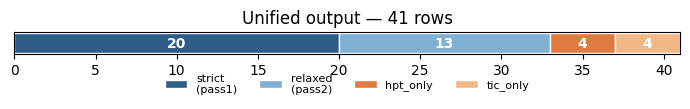

In [21]:
import matplotlib.pyplot as plt
labels = ["strict\n(pass1)","relaxed\n(pass2)","hpt_only","tic_only"]
vals = [stats.matches_pass1, stats.matches_pass2, stats.unmatched_hpt, stats.unmatched_tic]
colors = ["#2f5d8a","#7fb0d3","#e07a3e","#f2b885"]
fig, ax = plt.subplots(figsize=(7,1.6))
left = 0
for l,v,c in zip(labels, vals, colors):
    ax.barh(0, v, left=left, color=c, edgecolor="white"); 
    ax.text(left+v/2, 0, str(v), ha="center", va="center", color="white", fontweight="bold")
    left += v
ax.set_yticks([]); ax.set_xlim(0, sum(vals)); ax.set_title(f"Unified output — {sum(vals)} rows")
ax.legend(labels, loc="upper center", bbox_to_anchor=(0.5,-0.4), ncol=4, frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 7. Design decisions to be ready to defend

- **One row per `(ein, code, code_type, payer, billing_class)`**, both sides collapsed symmetrically; dispersion kept in min/max/count.
- **No "recommended rate"** — expose both rates + delta, let the consumer decide.
- **Billing class is inferred and weak** — `unknown` is recovered in Pass 2; exact rate agreement (Pass 3) can override it.
- **Comparability is surfaced, not assumed** — `hpt_methodology_mixed`, `tic_negotiation_types`, `cms_baseline_mixed` flag when a delta isn't like-for-like.
- **The hard parts are payer resolution and entity (EIN↔TIN↔NPI) resolution**, not the join — see the README's scaling and limitations sections.